# 5. Plot Generation

Generate business-facing plots for exploratory analysis, model comparison, forecast diagnostics, feature importance, weather demand, and the final XGBoost model decision.

In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bsdf.config import get_config
from bsdf.data import load_processed_data, split_time_ordered_data
from bsdf.features import add_time_features, create_feature_target_split
from bsdf.plotting import (
    plot_correlation_heatmap,
    plot_demand_trends,
    plot_error_distribution,
    plot_feature_importance,
    plot_model_comparison,
    plot_model_error_by_hour,
    plot_model_forecast_comparison,
    plot_model_metric_comparison,
    plot_weather_demand_analysis,
)
from bsdf.utils import load_model, save_table

CONFIG = get_config(PROJECT_ROOT)

## Pipeline Alignment

This notebook uses artifacts created by the previous pipeline notebooks:

- `1_data_ingestion.ipynb`: raw and clean data
- `2_feature_engineering.ipynb`: time, encoded, and scaled feature design
- `3_training.ipynb`: trained Linear Regression, Random Forest, Gradient Boosting, and XGBoost models
- `4_evaluation.ipynb`: model comparison table and best-model predictions

The selected business model is the model with the lowest mean absolute deviation in `model_comparison.csv`.

In [2]:
data = add_time_features(load_processed_data(CONFIG))
train_data, test_data = split_time_ordered_data(data, CONFIG.test_fraction)
X_test, y_test = create_feature_target_split(test_data)

comparison = pd.read_csv(CONFIG.processed_dir / "model_comparison.csv")
prediction_frame = pd.read_csv(CONFIG.processed_dir / "hourly_predictions_test.csv", parse_dates=["timestamp"])

model_names = comparison["model"].tolist()
trained_models = {
    model_name: load_model(CONFIG.model_dir / f"{model_name}.joblib")
    for model_name in model_names
}
best_model_name = comparison.iloc[0]["model"]
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best model MAD: {comparison.iloc[0]['mean_absolute_deviation']:.2f}")
comparison

Best model: xgboost
Best model MAD: 50.91


,model,mean_absolute_deviation,mean_absolute_percentage_error,r2_score
0,xgboost,50.905449,0.490943,0.886153
1,random_forest,53.471518,0.354383,0.868960
2,gradient_boosting,57.002632,0.608443,0.860422
3,linear_regression,98.690537,2.113512,0.631634


## Exploratory And Demand Pattern Plots

These plots explain demand shape, daily trend, weather effect, season effect, and feature relationships. Season and weather labels are rendered as names instead of numeric codes.

WindowsPath('C:/Users/Prompt/Desktop/New_Submission/Bike-Sharing-Demand-Forecasting/reports/figures/correlation_heatmap.png')

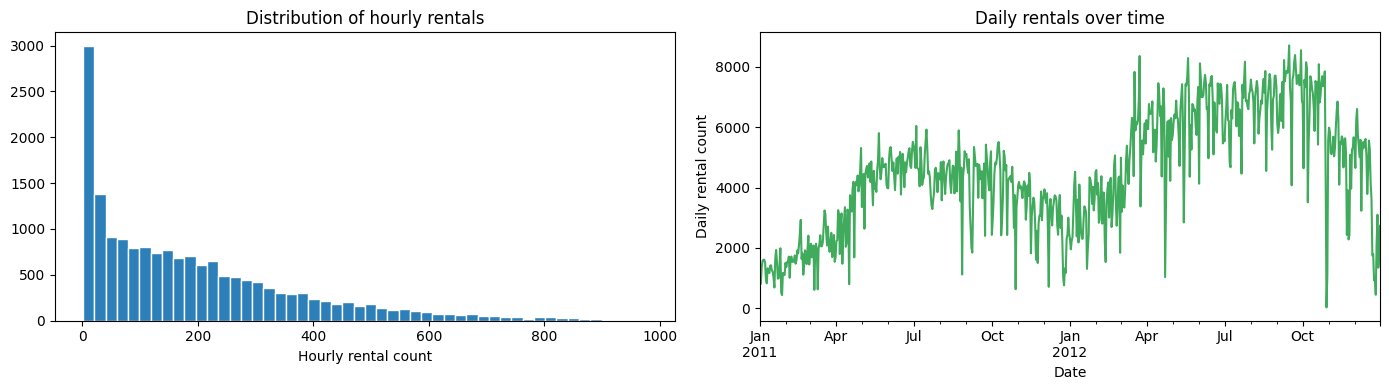

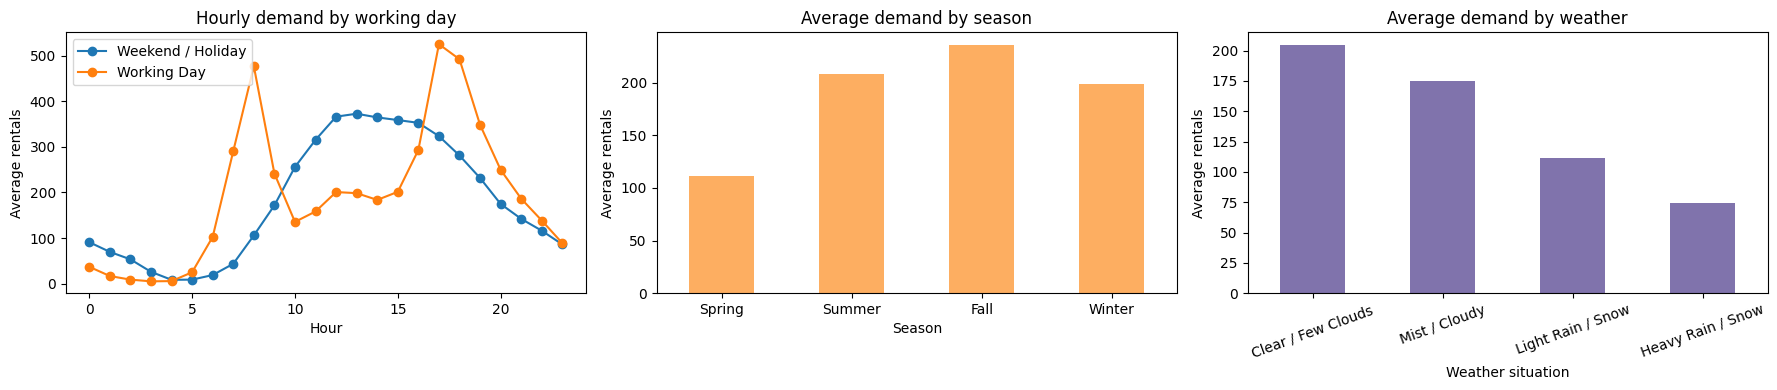

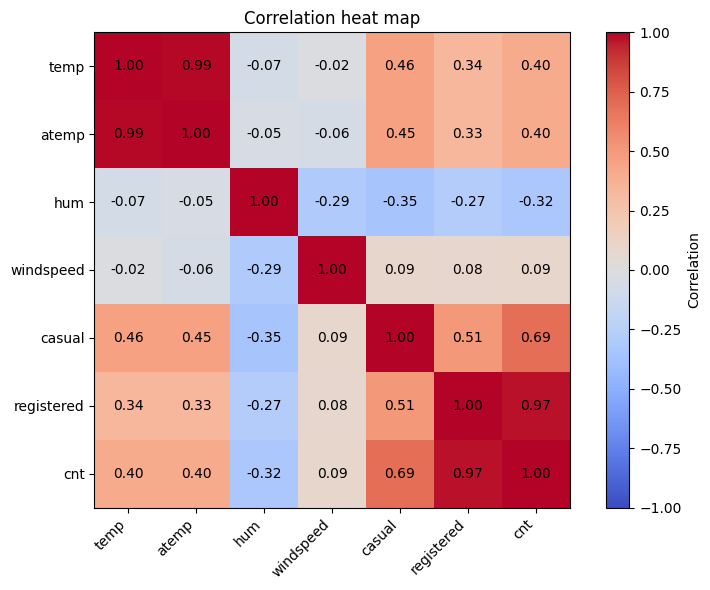

In [3]:
plot_demand_trends(data, CONFIG.figure_dir / "demand_trends.png")
plot_weather_demand_analysis(data, CONFIG.figure_dir / "weather_demand_analysis.png")
plot_correlation_heatmap(data, CONFIG.figure_dir / "correlation_heatmap.png")

## Model Comparison Plots

These visuals justify why XGBoost is selected. The comparison includes Linear Regression, Random Forest, Gradient Boosting, and XGBoost.

,model,hr,absolute_error
0,Gradient Boosting,0,26.733763
1,Gradient Boosting,1,19.643339
2,Gradient Boosting,2,17.667026
3,Gradient Boosting,3,19.435650
4,Gradient Boosting,4,9.182844


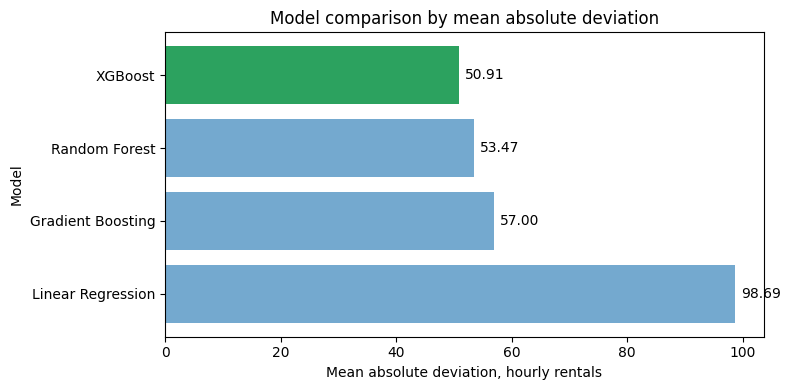

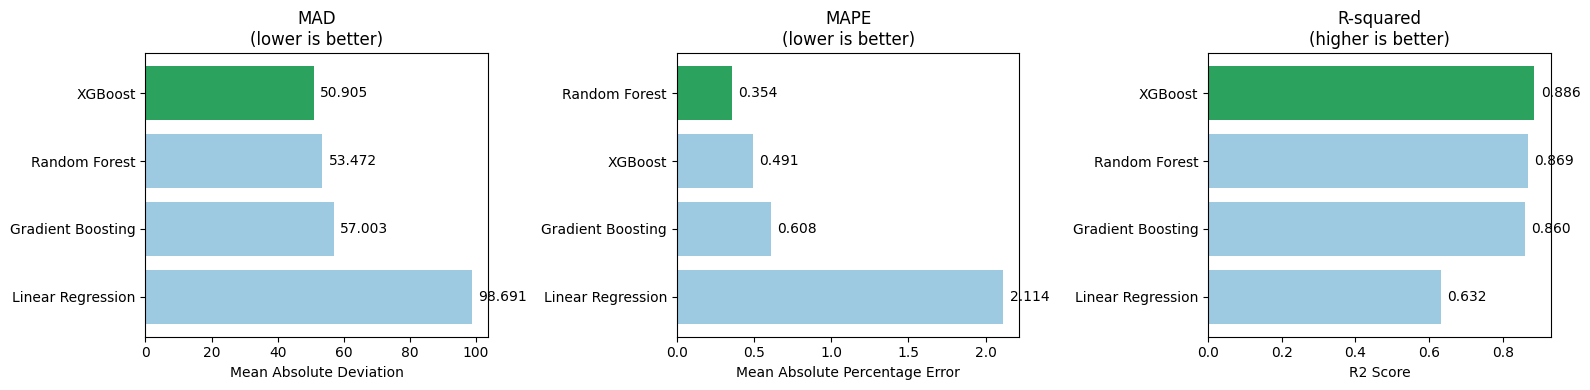

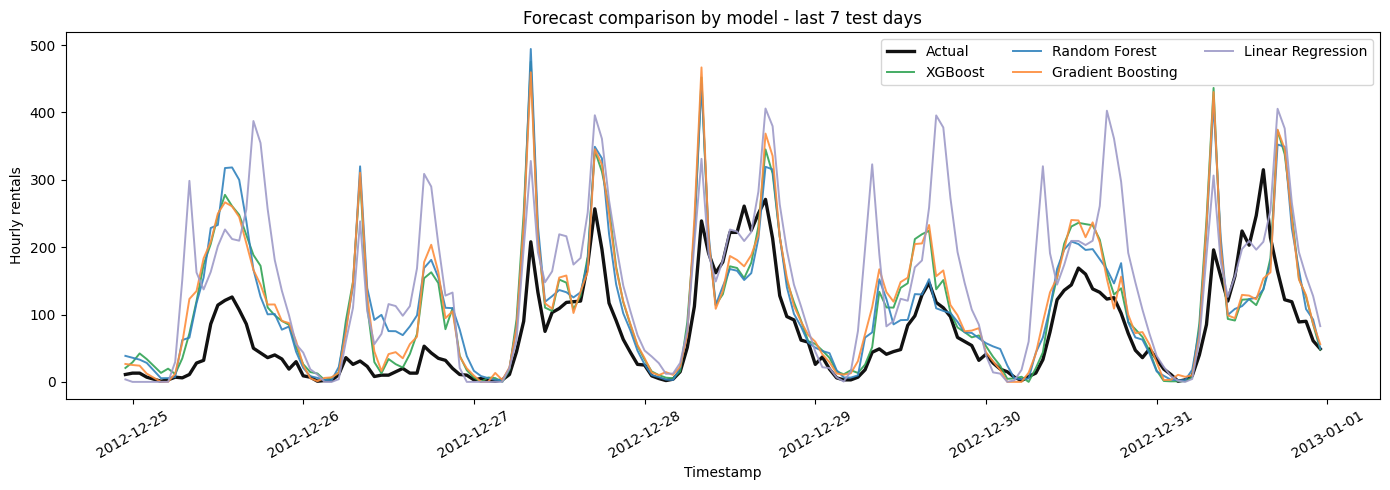

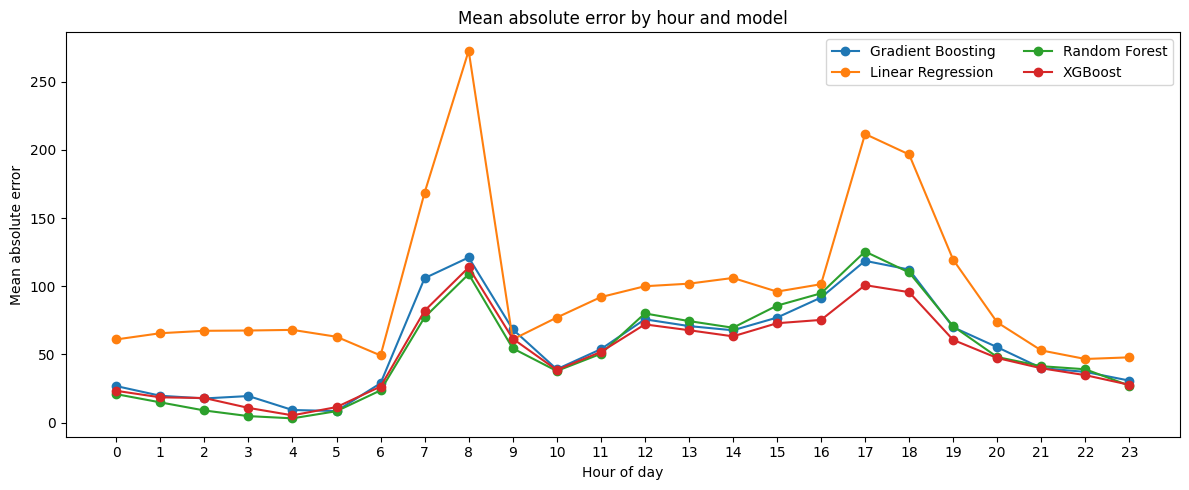

In [4]:
plot_model_comparison(comparison, CONFIG.figure_dir / "model_comparison.png")
plot_model_metric_comparison(comparison, CONFIG.figure_dir / "model_metric_comparison.png")
plot_model_forecast_comparison(
    trained_models,
    test_data,
    X_test,
    CONFIG.figure_dir / "model_forecast_comparison.png",
)
error_by_hour_by_model = plot_model_error_by_hour(
    trained_models,
    test_data,
    X_test,
    CONFIG.figure_dir / "model_error_by_hour.png",
)
save_table(error_by_hour_by_model, CONFIG.processed_dir / "model_error_by_hour.csv")
error_by_hour_by_model.head()

## Best Model Diagnostic Plots

These plots focus on the selected model, XGBoost, and show forecast error distribution plus feature importance.

,feature,importance
0,hour_cos,79.535610
1,hour_sin,60.051613
2,workingday,32.239518
3,hr,21.101558
4,atemp,10.067552
5,temp,7.479027
6,hum,6.464668
7,weekday,3.775881
8,weathersit,3.058411
9,season,1.729465


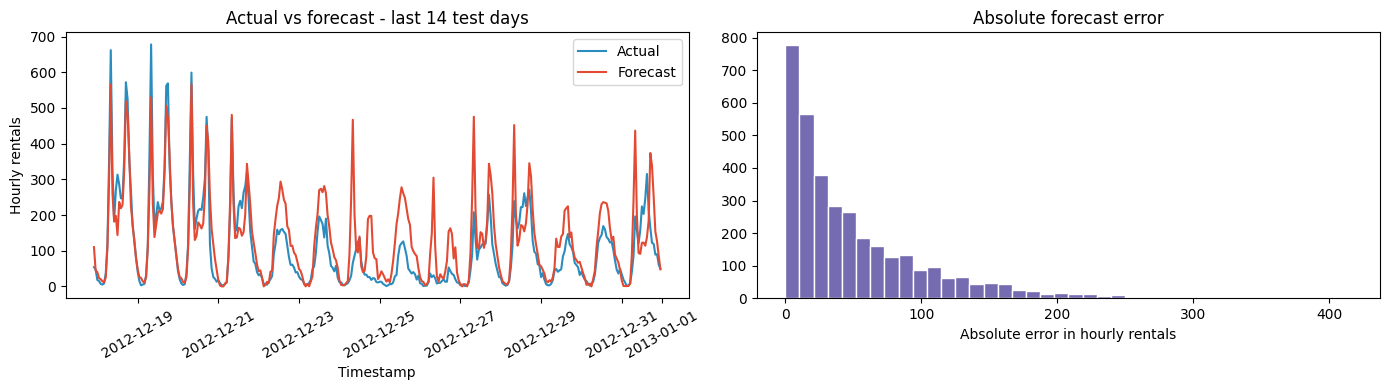

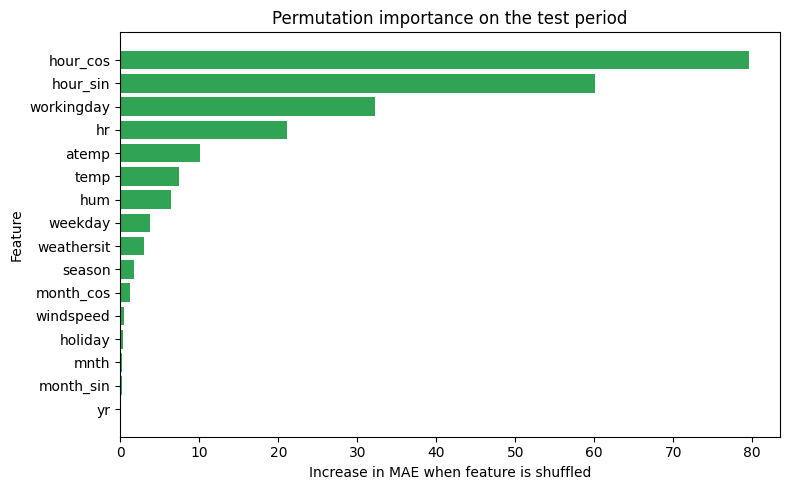

In [5]:
plot_error_distribution(prediction_frame, CONFIG.figure_dir / "error_distribution.png")
importance = plot_feature_importance(best_model, X_test, y_test, CONFIG.figure_dir / "feature_importance.png")
save_table(importance, CONFIG.processed_dir / "feature_importance.csv")
importance

## Generated Plot Files

- `demand_trends.png`
- `weather_demand_analysis.png`
- `correlation_heatmap.png`
- `model_comparison.png`
- `model_metric_comparison.png`
- `model_forecast_comparison.png`
- `model_error_by_hour.png`
- `error_distribution.png`
- `feature_importance.png`